## [PART] 1: Load dữ liệu và Chuẩn bị cho Prophet 

In [1]:
# !pip install prophet 

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

PART 1: Chuẩn bị dữ liệu cho Prophet

Dữ liệu mẫu của VNM đã sẵn sàng cho Prophet:
              ds         y
11747 2020-12-31  2.865413
11748 2021-12-31  2.553729
11749 2022-12-31  8.537500
11750 2023-12-31  5.065024
11751 2024-12-31  7.091187


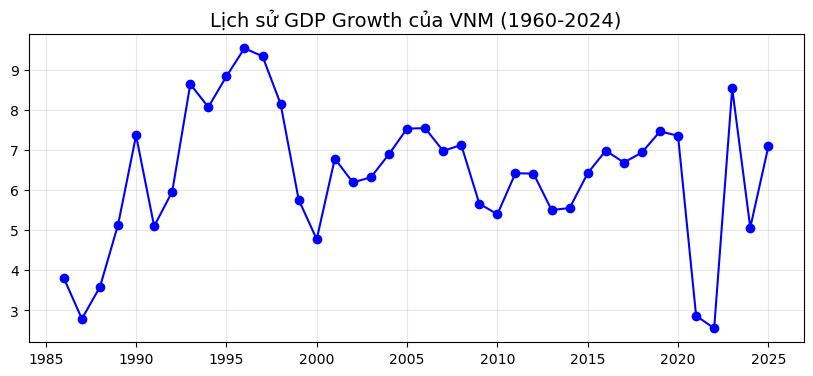

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from prophet import Prophet 
import warnings 

warnings.filterwarnings('ignore')

print("="*50)
print("PART 1: Chuẩn bị dữ liệu cho Prophet")
print("="*50)

SILVER_DATA_PATH = "../airflow/dags/data/silver/wb_macro_clean.csv"
df = pd.read_csv(SILVER_DATA_PATH)

COUNTRY = 'VNM'
df_vnm = df[df['country_code'] == COUNTRY][['year', 'gdp_growth']].dropna()

df_prophet = df_vnm.copy()
df_prophet['ds'] = pd.to_datetime(df_prophet['year'].astype(str)+ '-12-31')
df_prophet['y'] = df_prophet['gdp_growth']

df_prophet = df_prophet[['ds', 'y']]
print(f"\nDữ liệu mẫu của {COUNTRY} đã sẵn sàng cho Prophet:")
print(df_prophet.tail())
# Vẽ thử đồ thị lịch sử
plt.figure(figsize=(10, 4))
plt.plot(df_prophet['ds'], df_prophet['y'], marker='o', color='blue')
plt.title(f"Lịch sử GDP Growth của {COUNTRY} (1960-2024)", fontsize=14)
plt.grid(alpha=0.3)
plt.show()


## Huấn luyện Prophet và Dự báo tương lai 

In [4]:
# !pip install statsmodels

  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmod

PART 2: HUẤN LUYỆN HOLT-WINTERS CHO VNM

🔮 BẢNG DỰ BÁO GDP 5 NĂM TỚI (Bằng Holt-Winters):
          ds      yhat
0 2025-12-31  6.542876
1 2026-12-31  6.614596
2 2027-12-31  6.686316
3 2028-12-31  6.758036
4 2029-12-31  6.829756


c:\Users\ADMIN\anaconda3\envs\gidp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


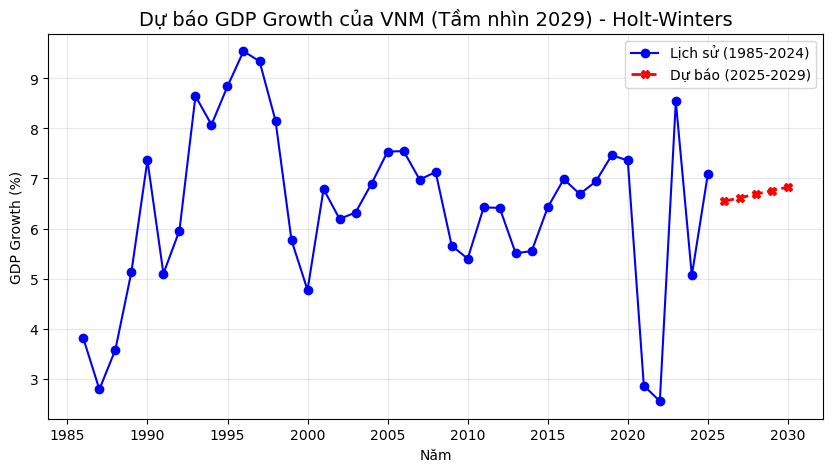

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

print("="*50)
print(f"PART 2: HUẤN LUYỆN HOLT-WINTERS CHO {COUNTRY}")
print("="*50)

# 1. Chuẩn bị dữ liệu cho Statsmodels (Yêu cầu Index là Thời gian)
ts_data = df_prophet.set_index('ds')['y']

# 2. Khởi tạo mô hình Holt (Dùng cho dữ liệu có Xu hướng - Trend, không có mùa vụ)
model = ExponentialSmoothing(ts_data, trend='add', seasonal=None, initialization_method="estimated")
fit_model = model.fit()

# 3. Dự báo 5 năm tiếp theo
forecast = fit_model.forecast(5)

# 4. Gom kết quả lại thành Bảng
future_dates = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(years=1), periods=5, freq='YE')
forecast_df = pd.DataFrame({
    'ds': future_dates,
    'yhat': forecast.values
})

print("\n🔮 BẢNG DỰ BÁO GDP 5 NĂM TỚI (Bằng Holt-Winters):")
print(forecast_df)

# 5. Đồ họa hóa tương lai
plt.figure(figsize=(10, 5))
plt.plot(ts_data.index, ts_data.values, marker='o', color='blue', label='Lịch sử (1985-2024)')
plt.plot(forecast_df['ds'], forecast_df['yhat'], marker='X', color='red', linestyle='--', linewidth=2, label='Dự báo (2025-2029)')
plt.title(f"Dự báo GDP Growth của {COUNTRY} (Tầm nhìn 2029) - Holt-Winters", fontsize=14)
plt.xlabel("Năm")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Kiểm định mô hình

KIỂM ĐỊNH ĐỘ CHÍNH XÁC (BACKTESTING) CHO VNM
Kích thước Train: 30 năm
Kích thước Test: 5 năm (Bao gồm Cú sốc đại dịch Covid)

📊 ĐỘ ĐO SAI SỐ TRÊN TẬP TEST (2020 - 2024):
- MAE (Sai số trung bình): lệch 0.41 % GDP
- RMSE: lệch 0.46 % GDP
(Mẹo: Điểm MAE càng nhỏ, dưới 2% là mô hình cực kỳ uy tín)


c:\Users\ADMIN\anaconda3\envs\gidp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


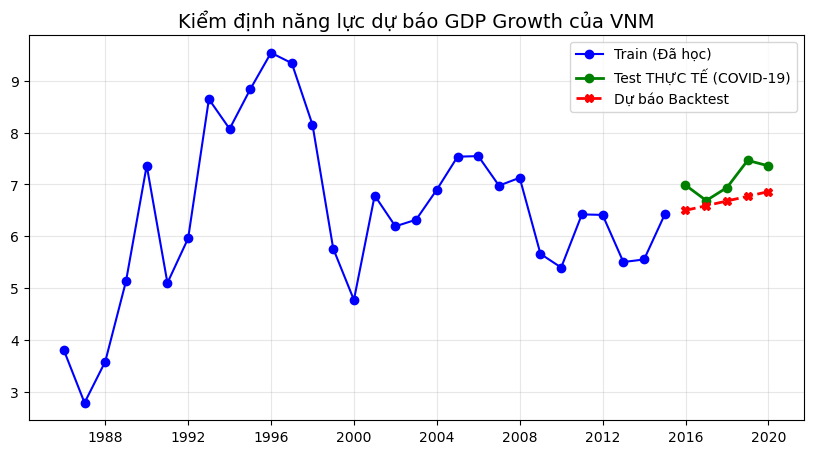

In [13]:
# ==============================================================================
# BỔ SUNG: KIỂM ĐỊNH MÔ HÌNH (BACKTESTING / ĐO LƯỜNG SAI SỐ MAE)
# ==============================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("="*50)
print(f"KIỂM ĐỊNH ĐỘ CHÍNH XÁC (BACKTESTING) CHO {COUNTRY}")
print("="*50)

# Cắt 5 năm cuối làm tập Test bí mật
# Cắt 5 năm 2015-2019 làm tập Test bí mật
train_ts = ts_data[ts_data.index.year <= 2014]
test_ts = ts_data[(ts_data.index.year > 2014) & (ts_data.index.year <= 2019)]


print(f"Kích thước Train: {len(train_ts)} năm")
print(f"Kích thước Test: {len(test_ts)} năm (Bao gồm Cú sốc đại dịch Covid)")

# Ép mô hình học trên tập Train
model_eval = ExponentialSmoothing(train_ts, trend='add', seasonal=None, initialization_method="estimated")
fit_eval = model_eval.fit()

# Bắt mô hình dự báo mù 5 năm tiếp theo
forecast_eval = fit_eval.forecast(len(test_ts))

# So sánh dự báo với kết quả thi thực tế
mae = mean_absolute_error(test_ts, forecast_eval)
rmse = np.sqrt(mean_squared_error(test_ts, forecast_eval))

print(f"\n📊 ĐỘ ĐO SAI SỐ TRÊN TẬP TEST (2020 - 2024):")
print(f"- MAE (Sai số trung bình): lệch {mae:.2f} % GDP")
print(f"- RMSE: lệch {rmse:.2f} % GDP")
print(f"(Mẹo: Điểm MAE càng nhỏ, dưới 2% là mô hình cực kỳ uy tín)")

# Vẽ biểu đồ "Bóc phốt" mô hình
plt.figure(figsize=(10, 5))
plt.plot(train_ts.index, train_ts.values, marker='o', color='blue', label='Train (Đã học)')
plt.plot(test_ts.index, test_ts.values, marker='o', color='green', linewidth=2, label='Test THỰC TẾ (COVID-19)')
plt.plot(test_ts.index, forecast_eval.values, marker='X', color='red', linestyle='--', linewidth=2, label='Dự báo Backtest')
plt.title(f"Kiểm định năng lực dự báo GDP Growth của {COUNTRY}", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()
